In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.cloud import storage
import io

In [2]:
df = pd.read_csv('../processed.csv')
print(df.columns)
df.head()

Index(['campaign', 'year', 'page', 'platform', 'media_type', 'category_l0',
       'category_l1', 'category_l2', 'url', 'content', 'cost_nzd', 'views',
       'hours', 'engagement', 'description_json', 'duration_seconds'],
      dtype='object')


,campaign,year,page,platform,media_type,category_l0,category_l1,category_l2,url,content,cost_nzd,views,hours,engagement,description_json,duration_seconds
0,Organic | Website,2025,ABXV,FB,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.facebook.com/reel/729678446160620/,@jacobkneepkens crosses the chalk 🤙,NaN,38409.0,64.3328,682.0,"{""play_by_play"": ""A male rugby player in a bla...",12.839229
1,Organic | Website,2025,ABXV,FB,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.facebook.com/reel/850774540642042/,@nanaiseturo 💨,NaN,235384.0,544.8062,3800.0,"{""play_by_play"": ""A male rugby player wearing ...",14.279229
2,Organic | Website,2025,ABXV,FB,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.facebook.com/reel/1120082556960744/,a classic rugby training drill 🏉,NaN,274028.0,712.1043,3261.0,"{""play_by_play"": ""A group of male rugby player...",19.644082
3,Organic | Website,2025,ABXV,FB,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.facebook.com/reel/1191989952906685/,"a great kick, a great backdrop 🎨",NaN,281319.0,623.9321,4929.0,"{""play_by_play"": ""A male rugby player runs up ...",15.625215
4,Organic | Website,2025,ABXV,FB,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.facebook.com/reel/1728500341153571/,a skill and a half 🚀,NaN,438181.0,894.3045,9850.0,"{""play_by_play"": ""A male All Black player trac...",13.605215


### extract json

In [3]:
# json schema
# {
# "play_by_play": "",
# "content_theme": [""],
# "format_access": [""],
# "people": [""],
# "brands": [""],
# "event": [""],
# "tone": [""],
# "context": [""],
# "overall_team": [""],
# "audio_format": [""]
# }

In [4]:
import json

JSON_LIST_FIELDS = [
    "content_theme", "format_access", "people", "brands",
    "event", "tone", "context", "overall_team", "audio_format",
]


def _parse_json(text):
    if text is None or (isinstance(text, float) and pd.isna(text)):
        return None
    try:
        return json.loads(text)
    except Exception:
        return None


json_dicts = df["description_json"].map(_parse_json)
df["description"] = json_dicts.map(
    lambda d: ((d or {}).get("play_by_play") or "").strip() or pd.NA
).astype("string")

# keep parsed dicts in scope for the encoding cell
json_by_idx = {idx: d for idx, d in zip(df.index, json_dicts) if d is not None}
print(f"parsed: {len(json_by_idx)} / {len(df)}")


parsed: 12105 / 12105


In [5]:
df = df[df['description'].notna()]

### encoding 

In [6]:
import json

JSON_LIST_FIELDS = [
    "content_theme", "format_access", "people", "brands",
    "event", "tone", "context", "overall_team", "audio_format",
]

# build per-field token-sets per row index for O(1) lookups
field_to_sets = {
    field: {idx: set(d.get(field, []) or []) for idx, d in json_by_idx.items()}
    for field in JSON_LIST_FIELDS
}

vocabulary = {
    field: {
        value
        for d in json_by_idx.values()
        for value in (d.get(field, []) or [])
    }
    for field in JSON_LIST_FIELDS
}

oh_columns = {
    f"json_{field}_{value}": pd.Series(
        [
            int(
                field_to_sets[field].get(idx) is not None
                and value in field_to_sets[field][idx]
            )
            for idx in df.index
        ],
        index=df.index,
        dtype="int8",
    )
    for field in JSON_LIST_FIELDS
    for value in sorted(vocabulary[field])
}

df = pd.concat([df, pd.DataFrame(oh_columns)], axis=1)

# raw JSON column no longer needed
df = df.drop(columns=["description_json"])


from collections import Counter

import regex

POST_TITLE_COLUMN = "content"
HASHTAG_PATTERN = regex.compile(r"(?<![\p{L}\p{N}_])#([\p{L}\p{N}_]+)")
MENTION_PATTERN = regex.compile(r"(?<![\p{L}\p{N}_@])@([\p{L}\p{N}_][\p{L}\p{N}_.]*)")
EMOJI_PATTERN = regex.compile(
    r"(?:\p{Regional_Indicator}{2}|[#*0-9]\uFE0F?\u20E3|"
    r"\p{Extended_Pictographic}(?:\uFE0F|\p{Emoji_Modifier})?"
    r"(?:\u200D\p{Extended_Pictographic}(?:\uFE0F|\p{Emoji_Modifier})?)*)"
)


def _multi_hot_encode(frame, token_lists, prefix, column_name, min_frequency):
    if min_frequency < 1:
        raise ValueError("min_frequency must be at least 1")

    old_columns = [column for column in frame.columns if column.startswith(f"{prefix}_")]
    if old_columns:
        frame.drop(columns=old_columns, inplace=True)

    unique_tokens = token_lists.map(lambda tokens: list(dict.fromkeys(tokens)))
    frequencies = Counter(token for tokens in unique_tokens for token in tokens)
    vocabulary = sorted(token for token, count in frequencies.items() if count >= min_frequency)

    new_columns = {
        f"{prefix}_count": token_lists.map(len).astype("int16"),
        **{
            column_name(token): unique_tokens.map(
                lambda tokens, value=token: int(value in tokens)
            ).astype("int8")
            for token in vocabulary
        },
    }
    frame = pd.concat([frame, pd.DataFrame(new_columns, index=frame.index)], axis=1)
    return frame


def hashtag_encode(frame, column=POST_TITLE_COLUMN, min_frequency=1):
    tokens = frame[column].fillna("").astype(str).map(
        lambda text: [tag.casefold() for tag in HASHTAG_PATTERN.findall(text)]
    )
    return _multi_hot_encode(
        frame, tokens, "hashtag", lambda tag: f"hashtag_{tag}", min_frequency
    )


def mention_encode(frame, column=POST_TITLE_COLUMN, min_frequency=1):
    tokens = frame[column].fillna("").astype(str).map(
        lambda text: [mention.rstrip(".").casefold() for mention in MENTION_PATTERN.findall(text)]
    )
    return _multi_hot_encode(
        frame, tokens, "mention", lambda mention: f"mention_{mention}", min_frequency
    )


def emoji_encode(frame, column=POST_TITLE_COLUMN, min_frequency=1):
    tokens = frame[column].fillna("").astype(str).map(EMOJI_PATTERN.findall)

    def emoji_column(value):
        codepoints = "_".join(f"{ord(char):x}" for char in value)
        return f"emoji_u{codepoints}"

    return _multi_hot_encode(frame, tokens, "emoji", emoji_column, min_frequency)


df = hashtag_encode(df)
df = mention_encode(df)
df = emoji_encode(df)
df.head()

,campaign,year,page,platform,media_type,category_l0,category_l1,category_l2,url,content,...,emoji_u1faf3_1f3fd,emoji_u1faf4_1f3fd,emoji_u1faf5,emoji_u1faf5_1f3fc,emoji_u1faf5_1f3fd,emoji_u1faf6,emoji_u1faf6_1f3fc,emoji_u1faf6_1f3fd,emoji_u1faf6_1f3fe,emoji_u1faf8
0,Organic | Website,2025,ABXV,FB,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.facebook.com/reel/729678446160620/,@jacobkneepkens crosses the chalk 🤙,...,0,0,0,0,0,0,0,0,0,0
1,Organic | Website,2025,ABXV,FB,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.facebook.com/reel/850774540642042/,@nanaiseturo 💨,...,0,0,0,0,0,0,0,0,0,0
2,Organic | Website,2025,ABXV,FB,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.facebook.com/reel/1120082556960744/,a classic rugby training drill 🏉,...,0,0,0,0,0,0,0,0,0,0
3,Organic | Website,2025,ABXV,FB,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.facebook.com/reel/1191989952906685/,"a great kick, a great backdrop 🎨",...,0,0,0,0,0,0,0,0,0,0
4,Organic | Website,2025,ABXV,FB,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.facebook.com/reel/1728500341153571/,a skill and a half 🚀,...,0,0,0,0,0,0,0,0,0,0


# NLP

### clustering descriptions

In [7]:
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans

texts = df['description'].tolist()

# Semantic embedding model
embedder = SentenceTransformer("all-MiniLM-L6-v2")

X = embedder.encode(texts, show_progress_bar=True)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/379 [00:00<?, ?it/s]

Best k: 3
Best silhouette score: 0.06132595


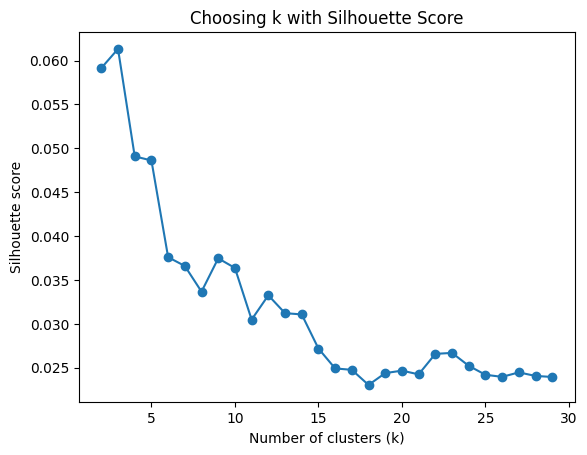

In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

k_range = range(2, 30)

silhouette_scores = []

for k in k_range:
    clusterer = KMeans(
        n_clusters=k,
        random_state=42,
        n_init="auto"
    )
    
    clusters = clusterer.fit_predict(X)
    
    score = silhouette_score(X, clusters)
    silhouette_scores.append(score)

# Find best k
best_k = k_range[silhouette_scores.index(max(silhouette_scores))]

print("Best k:", best_k)
print("Best silhouette score:", max(silhouette_scores))

# Plot
plt.plot(k_range, silhouette_scores, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Choosing k with Silhouette Score")
plt.show()

[1 2 1 ... 1 1 1]


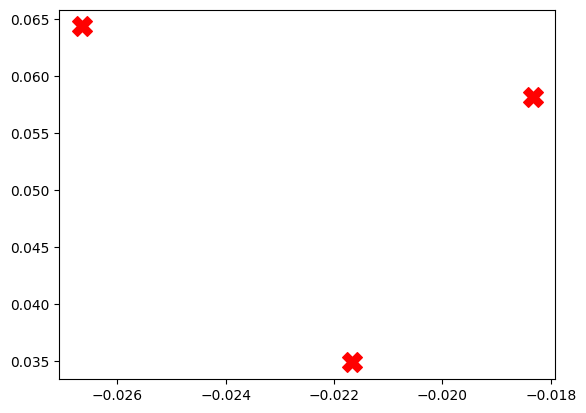

In [9]:
from sklearn.preprocessing import normalize

X_normalized = normalize(X)

clusterer = KMeans(
    # n_clusters=best_k,
    n_clusters=3,
    random_state=42,
    n_init="auto"
)

clusters = clusterer.fit_predict(X_normalized)
print(clusters)
df['description_cluster'] = clusters

centroids = clusterer.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids')


### clustering title

In [10]:
# from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans

texts = df['content'].tolist()

# Semantic embedding model
embedder = SentenceTransformer("all-MiniLM-L6-v2")

X = embedder.encode(texts, show_progress_bar=True)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/379 [00:00<?, ?it/s]

Best k: 12
Best silhouette score: 0.06871473


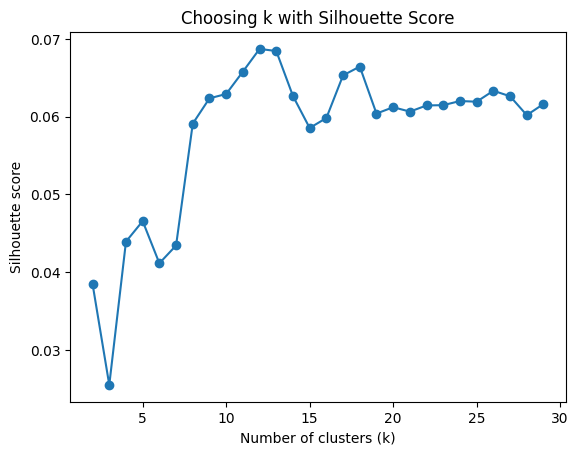

In [11]:

k_range = range(2, 30)

silhouette_scores = []

for k in k_range:
    clusterer = KMeans(
        n_clusters=k,
        random_state=42,
        n_init="auto"
    )
    
    clusters = clusterer.fit_predict(X)
    
    score = silhouette_score(X, clusters)
    silhouette_scores.append(score)

# Find best k
best_k = k_range[silhouette_scores.index(max(silhouette_scores))]

print("Best k:", best_k)
print("Best silhouette score:", max(silhouette_scores))

# Plot
plt.plot(k_range, silhouette_scores, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Choosing k with Silhouette Score")
plt.show()

[0 8 5 ... 3 3 3]


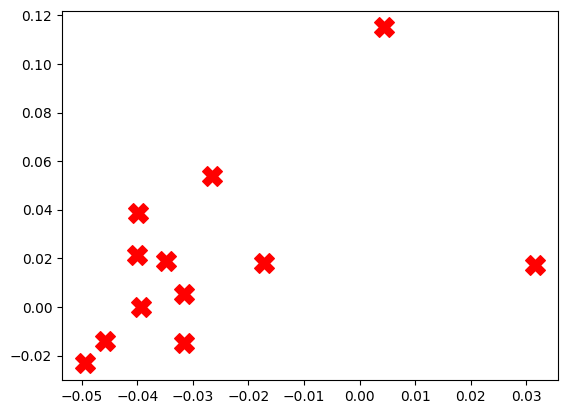

In [12]:
from sklearn.preprocessing import normalize

X_normalized = normalize(X)

clusterer = KMeans(
    # n_clusters=best_k,
    n_clusters=12,
    random_state=42,
    n_init="auto"
)

clusters = clusterer.fit_predict(X_normalized)
print(clusters)
df['title_cluster'] = clusters

centroids = clusterer.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids')


### drop stuff

In [13]:
# One-hot encode the high-cardinality categorical columns that were being
# dropped as raw strings. Adds columns named <col>_<value> for each value
# present in the data; constant columns (nunique == 1) are skipped so we
# don't add all-zero useless features.
from sklearn.preprocessing import OneHotEncoder

CATEGORICAL_TO_OH = [
    "platform", "page", "year",
    "category_l0", "category_l1", "category_l2",
]

for col in CATEGORICAL_TO_OH:
    n = df[col].nunique(dropna=True)
    flag = " (constant; skipped)" if n <= 1 else ""
    print(f"  {col}: nunique={n}{flag}")

oh_cols = [c for c in CATEGORICAL_TO_OH if df[c].nunique(dropna=True) > 0]
if oh_cols:
    oh = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
    encoded = pd.DataFrame(
        oh.fit_transform(df[oh_cols].astype(str)),
        columns=oh.get_feature_names_out(oh_cols),
        index=df.index,
    ).astype("int8")
    df = pd.concat([df, encoded], axis=1)
    print(f"added {encoded.shape[1]} one-hot columns from {oh_cols}")
else:
    print("no varying categorical columns to one-hot")

# Readable count features. The multi-hot encoder above already creates
# hashtag_count / mention_count / emoji_count; alias them to clearer
# names so they read naturally next to the model features.
for src, dst in [("mention_count", "n_mentions"),
                  ("hashtag_count", "n_hashtags"),
                  ("emoji_count",   "n_emojis")]:
    if src in df.columns and dst not in df.columns:
        df[dst] = df[src]

print("alias counts -> n_mentions / n_hashtags / n_emojis:")
for dst in ("n_mentions", "n_hashtags", "n_emojis"):
    if dst in df.columns:
        print(f"  {dst}: total={df[dst].sum():,}  mean={df[dst].mean():.2f}  max={df[dst].max()}")


  platform: nunique=4
  page: nunique=7
  year: nunique=4
  category_l0: nunique=7
  category_l1: nunique=25
  category_l2: nunique=74
added 121 one-hot columns from ['platform', 'page', 'year', 'category_l0', 'category_l1', 'category_l2']
alias counts -> n_mentions / n_hashtags / n_emojis:
  n_mentions: total=4,492  mean=0.37  max=7
  n_hashtags: total=19,314  mean=1.60  max=18
  n_emojis: total=15,129  mean=1.25  max=16


In [14]:
DROP = [
    'campaign',
    'platform',
    'media_type',
    "category_l0",
    "category_l1",
    "category_l2",
    "page",
    "platform",
    'url',
    'content',
    'hours',
    'description',
    'cost_nzd',
    'year'
]

df = df.drop(columns=DROP)

In [15]:
print(df.columns.tolist())

['views', 'engagement', 'duration_seconds', 'json_content_theme_celebration', 'json_content_theme_challenges', 'json_content_theme_conversion', 'json_content_theme_haka', 'json_content_theme_kick', 'json_content_theme_non rugby related', 'json_content_theme_player story', 'json_content_theme_rivalry', 'json_content_theme_rugby_skills', 'json_content_theme_run', 'json_content_theme_tackle', 'json_content_theme_training', 'json_content_theme_try', 'json_content_theme_undefined', 'json_format_access_announcement', 'json_format_access_archive', 'json_format_access_behind-the-scenes', 'json_format_access_candid clip', 'json_format_access_highlight', 'json_format_access_interview', 'json_format_access_montage', 'json_format_access_promotion', 'json_format_access_reaction', 'json_format_access_ticket sales', 'json_format_access_undefined', 'json_people_aaron cruden', 'json_people_aaron mauger', 'json_people_aaron reed', 'json_people_aaron smith', 'json_people_abigail paton', 'json_people_abig

In [232]:
# Q1 = df['views'].quantile(0.25)
# Q3 = df['views'].quantile(0.75)
# IQR = Q3 - Q1

# lower_bound = Q1 - 1.5 * IQR
# upper_bound = Q3 + 1.5 * IQR

In [233]:
# print(df['views'].isna().sum())
# df = df[(df['views'] >= lower_bound) & (df['views'] <= upper_bound)]
# df['views'].hist(bins=50)

In [234]:
# print(df['engagement'].isna().sum())
# df = df[(df['engagement'] >= lower_bound) & (df['engagement'] <= upper_bound)]
# df['engagement'].hist(bins=50)

## linreg views

In [235]:
# DROP_COLS = ['views', 'engagement']

# X = df.drop(columns=DROP_COLS)
# y = np.log1p(df['views'])


In [236]:
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2
# )

# print(len(X_train), len(X_test))
# print(len(y_train), len(y_test))

In [237]:
# from sklearn.linear_model import LinearRegression
# from sklearn.metrics import mean_squared_error,r2_score


# model = LinearRegression()
# model.fit(X_train, y_train)
# y_pred = model.predict(X_test)
# mse = mean_squared_error(y_test, y_pred)
# r2 = r2_score(y_test, y_pred)
# print(f"Mean Squared Error (MSE): {mse:.4f}")
# print(f"R-squared (R2) Score: {r2:.4f}")

# # 7. Plot predicted vs actual with a y=x reference line.
# y_test_array = np.asarray(y_test).ravel()
# y_pred_array = np.asarray(y_pred).ravel()
# residuals = y_test_array - y_pred_array
# ref_min = float(min(y_test_array.min(), y_pred_array.min()))
# ref_max = float(max(y_test_array.max(), y_pred_array.max()))

# plt.figure(figsize=(6, 6))
# scatter = plt.scatter(
#     y_test_array, y_pred_array, c=residuals, cmap='RdBu',
#     edgecolor='k', label='Predictions',
# )
# plt.plot([ref_min, ref_max], [ref_min, ref_max], 'k--', label='y_pred = y_test')
# plt.xlabel('Actual log(NZR - Views + 1)')
# plt.ylabel('Predicted log(NZR - Views + 1)')
# plt.title('Linear Regression: Predicted vs Actual')
# plt.colorbar(scatter, label='Residual (actual - predicted)')
# plt.legend()
# plt.show()

In [238]:
# important_features = sorted(zip(model.coef_, X_train.columns))

# print('top 5 negative:')
# for t in important_features[:5]:
#     print(t[0], t[1])

# print('top 5 positive:')
# for t in reversed(important_features[-5:]):
#     print(t[0], t[1])


## linreg engagement

In [239]:
# X = df.drop(columns=DROP_COLS)

# y = np.log1p(df['engagement'])

In [240]:
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2
# )

# print(len(X_train), len(X_test))
# print(len(y_train), len(y_test))

In [241]:
# model = LinearRegression()
# model.fit(X_train, y_train)
# y_pred = model.predict(X_test)
# mse = mean_squared_error(y_test, y_pred)
# r2 = r2_score(y_test, y_pred)
# print(f"Mean Squared Error (MSE): {mse:.4f}")
# print(f"R-squared (R2) Score: {r2:.4f}")

# y_test_array = np.asarray(y_test).ravel()
# y_pred_array = np.asarray(y_pred).ravel()
# residuals = y_test_array - y_pred_array
# ref_min = float(min(y_test_array.min(), y_pred_array.min()))
# ref_max = float(max(y_test_array.max(), y_pred_array.max()))

# plt.figure(figsize=(6, 6))
# scatter = plt.scatter(
#     y_test_array, y_pred_array, c=residuals, cmap='RdBu',
#     edgecolor='k', label='Predictions',
# )
# plt.plot([ref_min, ref_max], [ref_min, ref_max], 'k--', label='y_pred = y_test')
# plt.xlabel('Actual log(NZR - Engagement + 1)')
# plt.ylabel('Predicted log(NZR - Engagement + 1)')
# plt.title('Linear Regression: Predicted vs Actual')
# plt.colorbar(scatter, label='Residual (actual - predicted)')
# plt.legend()
# plt.show()

In [242]:
# important_features = sorted(zip(model.coef_, X_train.columns))

# print('top 5 negative:')
# for t in important_features[:5]:
#     print(t[0], t[1])

# print('top 5 positive:')
# for t in reversed(important_features[-5:]):
#     print(t[0], t[1])

### LINREG NN

In [109]:
mask = (df['views'] > 0) & (df['engagement'] > 0)
print(f"drop {(~mask).sum()} rows; remaining: {len(df) - (~mask).sum()}")
df = df[mask]

drop 0 rows; remaining: 11279


In [110]:
df_copy = df.copy()

In [111]:
print(len(df))
Q1 = df_copy['views'].quantile(0.1)
Q3 = df_copy['views'].quantile(0.9)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_copy = df_copy[(df_copy['views'] >= lower_bound) & (df_copy['views'] <= upper_bound)]


Q1 = df_copy['engagement'].quantile(0.1)
Q3 = df_copy['engagement'].quantile(0.9)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_copy = df_copy[(df_copy['engagement'] >= lower_bound) & (df_copy['engagement'] <= upper_bound)]
print(len(df_copy))

11279
10760


In [112]:
# from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split


DROP_COLS = ['views', 'engagement']

X = df_copy.drop(columns=DROP_COLS)
# y = np.log1p(df[['engagement','views']])
y = df_copy[['engagement', 'views']]

# y = scaler.fit_transform(df[['engagement']])


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

print(len(X_train), len(X_test))
print(len(y_train), len(y_test))

# scaler = StandardScaler()
# scaler.fit(X_train)
# X_train_scaled = scaler.transform(X_train)
# X_test_scaled = scaler.transform(X_test)

scaler = RobustScaler()
scaler.fit(y_train)

y_train = scaler.transform(y_train)
y_test = scaler.transform(y_test)

print(X_train.shape)

8608 2152
8608 2152
(8608, 6446)


In [113]:
from keras import Input
from keras import Sequential, layers

model = Sequential()
model.add(Input(shape=(X.shape[1],)))


model.add(layers.Dense(1611, activation='relu'))
model.add(layers.Dropout(rate=0.2))
model.add(layers.Dense(402, activation='relu'))
model.add(layers.Dropout(rate=0.2)) 
model.add(layers.Dense(100, activation='relu'))
model.add(layers.Dropout(rate=0.2)) 
model.add(layers.Dense(25, activation='relu'))
model.add(layers.Dropout(rate=0.2))
model.add(layers.Dense(6, activation='relu'))
model.add(layers.Dropout(rate=0.2))
model.add(layers.Dense(2, activation='linear'))
# model.add(layers.Dense(1, activation='linear'))


model.compile(loss='mse', optimizer='adam', metrics=['mae'])
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_48 (Dense)                │ (None, 1611)           │    10,386,117 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 1611)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 402)            │       648,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 402)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 100)            │        40,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 25)             │         2,525 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 6)              │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 2)              │            14 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,077,136 (42.26 MB)

 Trainable params: 11,077,136 (42.26 MB)

 Non-trainable params: 0 (0.00 B)

In [114]:
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau

es = EarlyStopping(patience=20, restore_best_weights=True, monitor='val_loss' )
rop = ReduceLROnPlateau(factor=0.5, patience=3, monitor='val_loss')

history = model.fit(X_train, y_train, batch_size=8, epochs=1000, validation_split=0.2, callbacks=[es, rop])

Epoch 1/1000
861/861 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - loss: 1.4886 - mae: 0.7329 - val_loss: 0.9444 - val_mae: 0.5994 - learning_rate: 0.0010
Epoch 2/1000
861/861 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - loss: 1.1635 - mae: 0.6624 - val_loss: 0.9884 - val_mae: 0.6068 - learning_rate: 0.0010
Epoch 3/1000
861/861 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - loss: 1.0353 - mae: 0.6228 - val_loss: 0.9365 - val_mae: 0.5809 - learning_rate: 0.0010
Epoch 4/1000
861/861 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - loss: 0.9999 - mae: 0.6114 - val_loss: 0.9634 - val_mae: 0.5988 - learning_rate: 0.0010
Epoch 5/1000
861/861 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - loss: 0.9361 - mae: 0.5886 - val_loss: 0.8954 - val_mae: 0.5610 - learning_rate: 0.0010
Epoch 6/1000
861/861 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - loss: 0.8632 - mae: 0.5654 - val_loss: 0.9186 - val_mae: 0.5864 - learning_rate: 0.0010
Epoch 7/1000
861/861 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - loss: 0.8029 - mae: 0.5472 - val_loss: 0.8805 - val_mae: 0.5467 - 

(<Figure size 1500x500 with 3 Axes>,
 array([<Axes: title={'center': 'Loss'}, xlabel='Epochs', ylabel='Loss'>,
        <Axes: title={'center': 'MAE'}, xlabel='Epochs', ylabel='MAE'>,
        <Axes: title={'center': 'Learning rate'}, xlabel='Epochs', ylabel='Learning rate'>],
       dtype=object))

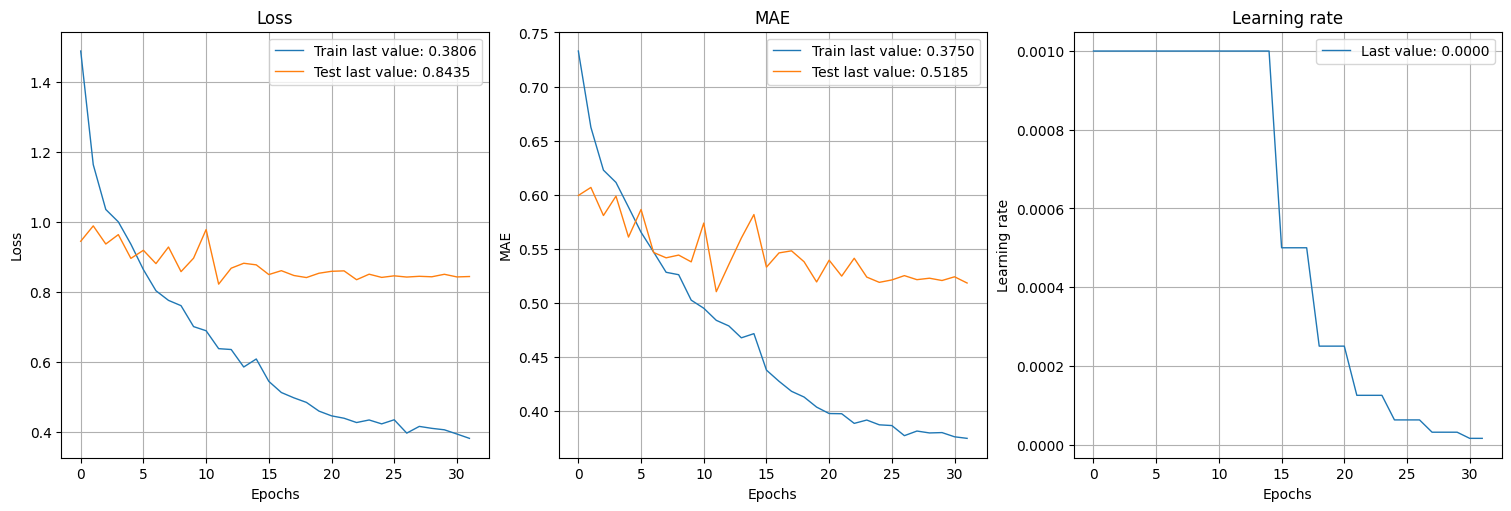

In [115]:
from plot_keras_history import plot_history

plot_history(history)

In [116]:
results = model.evaluate(X_test, y_test)
# print(results)
print(f"Test Loss: {results[0]}")
print(f"Test MAE: {results[1]}")

68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7856 - mae: 0.5114 
Test Loss: 0.7856375575065613
Test MAE: 0.5113743543624878


In [117]:
# ---- MAE in both spaces ----
# results[1] is the model's MAE in RobustScaler-scaled engagement units.
# To express it in raw engagement units, multiply by the scaler's IQR-scale.
nn_mae_scaled = float(results[1])
mae_raw = nn_mae_scaled * scaler.scale_[0]

# ---- Predicted engagement range around a chosen dummy value ----
dummy_views = 10_000
low  = round(dummy_views - mae_raw, -3)
high = round(dummy_views + mae_raw, -3)

print(f"scaled MAE: {nn_mae_scaled:.4f}   raw MAE: ~{mae_raw:,.0f} engagement")
print(f"{low:,.0f} <-- {dummy_views:,} --> {high:,.0f}")

# ---- Apples-to-apples baseline ----
# RobustScaler centres on the median, so the right "predict the centre" baseline
# is np.median(y_train) (which is approximately 0 after the transform).
baseline_mae_scaled = float(np.mean(np.abs(y_test - np.median(y_train))))
nn_mae_scaled       = float(results[1])

print(f"baseline mae (median, scaled): {baseline_mae_scaled:.4f}")
print(f"model mae (scaled):           {nn_mae_scaled:.4f}")
print(f"Model better than baseline by         {baseline_mae_scaled - nn_mae_scaled:.3f}")


scaled MAE: 0.5114   raw MAE: ~3,945 engagement
6,000 <-- 10,000 --> 14,000
baseline mae (median, scaled): 0.7102
model mae (scaled):           0.5114
Model better than baseline by         0.199


In [331]:
# scaled MAE: 0.5064   raw MAE: ~1,986 engagement
# 8,000 <-- 10,000 --> 12,000
# baseline mae (median, scaled): 0.7350
# model mae (scaled):           0.5064
# Model better than baseline by         0.229

### CLAS NN (permutation)

In [102]:
mask = (df['views'] > 0) & (df['engagement'] > 0)
print(f"drop {(~mask).sum()} rows; remaining: {len(df) - (~mask).sum()}")
df = df[mask]

drop 0 rows; remaining: 11279


In [103]:
df_copy = df.copy()

In [104]:
print(len(df))
Q1 = df_copy['views'].quantile(0)
Q3 = df_copy['views'].quantile(1)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_copy = df_copy[(df_copy['views'] >= lower_bound) & (df_copy['views'] <= upper_bound)]


Q1 = df_copy['engagement'].quantile(0.1)
Q3 = df_copy['engagement'].quantile(0.9)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_copy = df_copy[(df_copy['engagement'] >= lower_bound) & (df_copy['engagement'] <= upper_bound)]
print(len(df_copy))

11279
10937


In [105]:
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical

N_BINS = 2

def _iqr_binned(series, n=N_BINS):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    edges = np.linspace(q1 - 1.5 * iqr, q3 + 1.5 * iqr, n + 1)
    return np.clip(np.digitize(series.to_numpy(), edges) - 1, 0, n - 1).astype(int)

views_bin = _iqr_binned(df_copy['views'])
engagement_bin = _iqr_binned(df_copy['engagement'])

y_categories = pd.Categorical(
    [f"views_{v}_engagement_{e}" for v, e in zip(views_bin, engagement_bin)]
)
y = to_categorical(y_categories.codes, num_classes=N_BINS * N_BINS)
y_label = pd.Series(y_categories.categories[y_categories.codes], index=df_copy.index)

DROP_COLS = ['views', 'engagement']
X = df_copy.drop(columns=DROP_COLS)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [106]:
print(X.shape)
print(y.shape)

codes_train = y_train.argmax(axis=1)
counts = pd.Series(codes_train).value_counts().sort_index()
for code, n in counts.items():
    print(f"  {y_categories.categories[code]}: {n}")
print(f"\nTotal test rows: {len(codes_train)}")

(10937, 6446)
(10937, 4)
  views_0_engagement_0: 5085
  views_0_engagement_1: 385
  views_1_engagement_0: 471
  views_1_engagement_1: 2808

Total test rows: 8749


In [107]:
from keras import Input
from keras import Sequential, layers

model = Sequential()
model.add(Input(shape=(X.shape[1],)))


model.add(layers.Dense(1611, activation='relu'))
model.add(layers.Dropout(rate=0.2))
model.add(layers.Dense(402, activation='relu'))
model.add(layers.Dropout(rate=0.2)) 
model.add(layers.Dense(100, activation='relu'))
model.add(layers.Dropout(rate=0.2)) 
model.add(layers.Dense(25, activation='relu'))
model.add(layers.Dropout(rate=0.2))
model.add(layers.Dense(6, activation='relu'))
model.add(layers.Dropout(rate=0.2))
model.add(layers.Dense(y.shape[1], activation='softmax'))


model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 1611)           │    10,386,117 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 1611)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 402)            │       648,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 402)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 100)            │        40,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 25)             │         2,525 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 6)              │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4)              │            28 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,077,150 (42.26 MB)

 Trainable params: 11,077,150 (42.26 MB)

 Non-trainable params: 0 (0.00 B)

In [108]:
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau

es = EarlyStopping(patience=20, restore_best_weights=True, monitor='val_loss' )
rop = ReduceLROnPlateau(factor=0.5, patience=3, monitor='val_loss')

history = model.fit(X_train, y_train, batch_size=32, epochs=1000, validation_split=0.2, callbacks=[es, rop])

Epoch 1/1000
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.6019 - loss: 0.5716 - val_accuracy: 0.7674 - val_loss: 0.4383 - learning_rate: 0.0010
Epoch 2/1000
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.7024 - loss: 0.4346 - val_accuracy: 0.7520 - val_loss: 0.3624 - learning_rate: 0.0010
Epoch 3/1000
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.7222 - loss: 0.3701 - val_accuracy: 0.7651 - val_loss: 0.3507 - learning_rate: 0.0010
Epoch 4/1000
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.7715 - loss: 0.3217 - val_accuracy: 0.7903 - val_loss: 0.2948 - learning_rate: 0.0010
Epoch 5/1000
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.7940 - loss: 0.2716 - val_accuracy: 0.7754 - val_loss: 0.2970 - learning_rate: 0.0010
Epoch 6/1000
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.8050 - loss: 0.2481 - val_accuracy: 0.7674 - val_loss: 0.3089 - learning_rate: 0.0010
Epoch 7/1000
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.8

(<Figure size 1500x500 with 3 Axes>,
 array([<Axes: title={'center': 'Accuracy'}, xlabel='Epochs', ylabel='Accuracy'>,
        <Axes: title={'center': 'Loss'}, xlabel='Epochs', ylabel='Loss'>,
        <Axes: title={'center': 'Learning rate'}, xlabel='Epochs', ylabel='Learning rate'>],
       dtype=object))

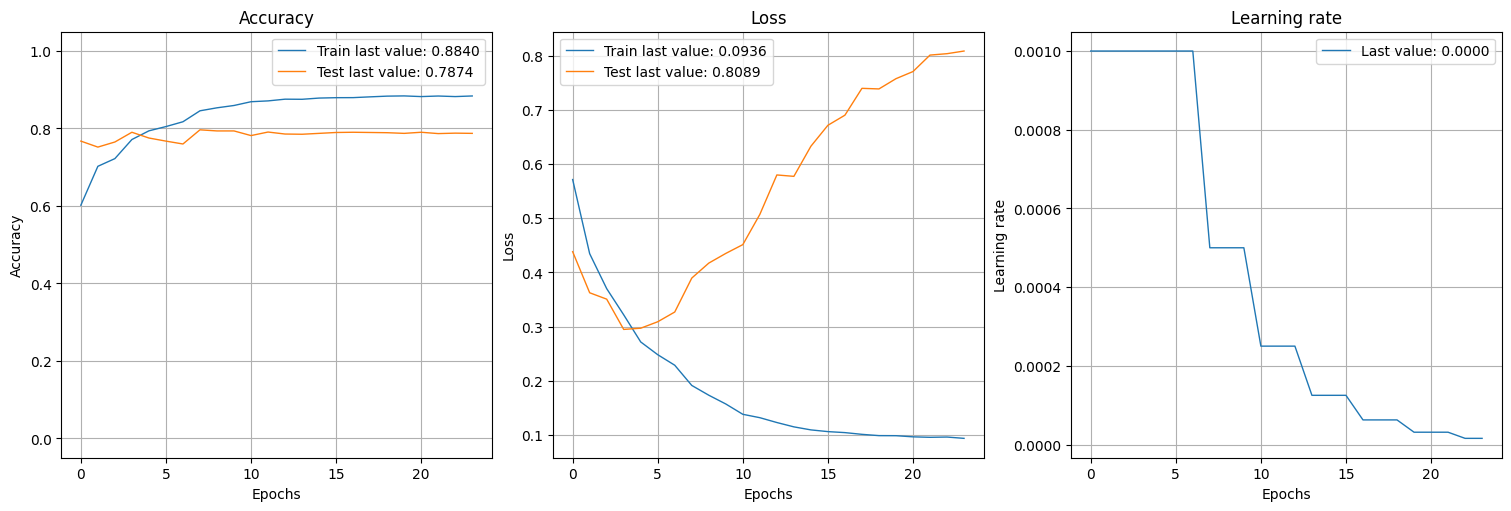

In [109]:
from plot_keras_history import plot_history

plot_history(history)

In [110]:
results = model.evaluate(X_test, y_test)
# print(results)
print(f"Test Loss: {results[0]}")
print(f"Test Accuracy: {results[1]}")

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7797 - loss: 0.3204 
Test Loss: 0.3203742206096649
Test Accuracy: 0.7797074913978577


In [111]:
from sklearn.metrics import accuracy_score

codes_train = y_train.argmax(axis=1)
codes_test = y_test.argmax(axis=1)

majority_class = int(pd.Series(codes_train).mode().iloc[0])
majority_label = y_categories.categories[majority_class]
majority_share = float(pd.Series(codes_train).value_counts(normalize=True).iloc[0])

baseline_pred = np.full(len(y_test), majority_class, dtype=int)
baseline_acc = accuracy_score(codes_test, baseline_pred)
model_acc = float(results[1])

print(f"majority class:         {majority_label}")
print(f"majority share (train): {majority_share:.4f}")
print(f"baseline accuracy:      {baseline_acc:.4f}")
print(f"model accuracy:         {model_acc:.4f}")
print(f"model - baseline:       {model_acc - baseline_acc:+.4f}")

majority class:         views_0_engagement_0
majority share (train): 0.5812
baseline accuracy:      0.5727
model accuracy:         0.7797
model - baseline:       +0.2070


### CLAS NN (2head)

In [251]:
mask = (df['views'] > 0) & (df['engagement'] > 0)
print(f"drop {(~mask).sum()} rows; remaining: {len(df) - (~mask).sum()}")
df = df[mask]

drop 0 rows; remaining: 11279


In [252]:
df_copy = df.copy()

In [253]:
print(len(df))
Q1 = df_copy['views'].quantile(0)
Q3 = df_copy['views'].quantile(1)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_copy = df_copy[(df_copy['views'] >= lower_bound) & (df_copy['views'] <= upper_bound)]


Q1 = df_copy['engagement'].quantile(0)
Q3 = df_copy['engagement'].quantile(1)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_copy = df_copy[(df_copy['engagement'] >= lower_bound) & (df_copy['engagement'] <= upper_bound)]
print(len(df_copy))

11279
11279


In [254]:
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical

N_BINS = 2

def _iqr_binned(series, n=N_BINS):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    edges = np.linspace(q1 - 1.5 * iqr, q3 + 1.5 * iqr, n + 1)
    return np.clip(np.digitize(series.to_numpy(), edges) - 1, 0, n - 1).astype(int)

views_bin = _iqr_binned(df_copy['views'])
engagement_bin = _iqr_binned(df_copy['engagement'])

y_views = to_categorical(views_bin, num_classes=N_BINS)
y_engagement = to_categorical(engagement_bin, num_classes=N_BINS)

DROP_COLS = ['views', 'engagement']
X = df_copy.drop(columns=DROP_COLS)

X_train, X_test, y_views_train, y_views_test, y_engagement_train, y_engagement_test = train_test_split(
    X, y_views, y_engagement, test_size=0.2, random_state=42
)

In [255]:
print("X:            ", X.shape)
print("y_views:      ", y_views.shape)
print("y_engagement: ", y_engagement.shape)

print("\nviews_bin distribution (train):")
codes = y_views_train.argmax(axis=1)
for code, n in pd.Series(codes).value_counts().sort_index().items():
    print(f"  views_bin_{code}: {n}")
print(f"  total train rows: {len(codes)}")

print("\nengagement_bin distribution (train):")
codes = y_engagement_train.argmax(axis=1)
for code, n in pd.Series(codes).value_counts().sort_index().items():
    print(f"  engagement_bin_{code}: {n}")
print(f"  total train rows: {len(codes)}")

X:             (11279, 6446)
y_views:       (11279, 2)
y_engagement:  (11279, 2)

views_bin distribution (train):
  views_bin_0: 5664
  views_bin_1: 3359
  total train rows: 9023

engagement_bin distribution (train):
  engagement_bin_0: 5727
  engagement_bin_1: 3296
  total train rows: 9023


In [256]:
from keras import Input
from keras.models import Model
from keras import layers

shared_input = Input(shape=(X.shape[1],))
x = layers.Dense(1611, activation='relu')(shared_input)
x = layers.Dropout(rate=0.2)(x)
x = layers.Dense(402, activation='relu')(x)
x = layers.Dropout(rate=0.2)(x)
x = layers.Dense(100, activation='relu')(x)
x = layers.Dropout(rate=0.2)(x)
x = layers.Dense(25, activation='relu')(x)
x = layers.Dropout(rate=0.2)(x)
# x = layers.Dense(6, activation='relu')(x)

views_head = layers.Dense(N_BINS, activation='softmax', name='views')(x)
engagement_head = layers.Dense(N_BINS, activation='softmax', name='engagement')(x)

model = Model(inputs=shared_input, outputs=[views_head, engagement_head])

model.compile(
    loss={'views': 'categorical_crossentropy', 'engagement': 'categorical_crossentropy'},
    optimizer='adam',
    metrics={'views': 'accuracy', 'engagement': 'accuracy'},
)
model.summary()

Model: "functional_47"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_17      │ (None, 6446)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_74 (Dense)    │ (None, 1611)      │ 10,386,117 │ input_layer_17[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_64          │ (None, 1611)      │          0 │ dense_74[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_75 (Dense)    │ (None, 402)       │    648,024 │ dropout_64[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_65          │ (None, 402)       │          0 │ dense_75[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_76 (Dense)    │ (None, 100)       │     40,300 │ dropout_65[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_66          │ (None, 100)       │          0 │ dense_76[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_77 (Dense)    │ (None, 25)        │      2,525 │ dropout_66[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_67          │ (None, 25)        │          0 │ dense_77[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ views (Dense)       │ (None, 2)         │         52 │ dropout_67[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ engagement (Dense)  │ (None, 2)         │         52 │ dropout_67[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 11,077,070 (42.26 MB)

 Trainable params: 11,077,070 (42.26 MB)

 Non-trainable params: 0 (0.00 B)

In [257]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

es = EarlyStopping(patience=20, restore_best_weights=True, monitor='val_loss')
rop = ReduceLROnPlateau(factor=0.5, patience=3, monitor='val_loss')

history = model.fit(
    X_train,
    {'views': y_views_train, 'engagement': y_engagement_train},
    batch_size=32,
    epochs=1000,
    validation_split=0.2,
    callbacks=[es, rop],
)

Epoch 1/1000
226/226 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - engagement_accuracy: 0.7576 - engagement_loss: 0.5076 - loss: 1.0398 - views_accuracy: 0.7474 - views_loss: 0.5317 - val_engagement_accuracy: 0.8116 - val_engagement_loss: 0.4222 - val_loss: 0.9001 - val_views_accuracy: 0.7884 - val_views_loss: 0.4780 - learning_rate: 0.0010
Epoch 2/1000
226/226 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - engagement_accuracy: 0.8448 - engagement_loss: 0.3655 - loss: 0.7651 - views_accuracy: 0.8292 - views_loss: 0.3996 - val_engagement_accuracy: 0.8471 - val_engagement_loss: 0.3593 - val_loss: 0.7759 - val_views_accuracy: 0.8083 - val_views_loss: 0.4187 - learning_rate: 0.0010
Epoch 3/1000
226/226 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - engagement_accuracy: 0.8741 - engagement_loss: 0.3099 - loss: 0.6502 - views_accuracy: 0.8570 - views_loss: 0.3402 - val_engagement_accuracy: 0.8443 - val_engagement_loss: 0.3713 - val_loss: 0.7783 - val_views_accuracy: 0.8216 - val_views_loss: 0.4096 - learning_rate: 0.0010
E

(<Figure size 2000x1000 with 8 Axes>,
 array([[<Axes: title={'center': 'Engagement Accuracy'}, xlabel='Epochs', ylabel='Engagement Accuracy'>,
         <Axes: title={'center': 'Engagement loss'}, xlabel='Epochs', ylabel='Engagement loss'>,
         <Axes: title={'center': 'Loss'}, xlabel='Epochs', ylabel='Loss'>,
         <Axes: title={'center': 'Views Accuracy'}, xlabel='Epochs', ylabel='Views Accuracy'>],
        [<Axes: title={'center': 'Views loss'}, xlabel='Epochs', ylabel='Views loss'>,
         <Axes: title={'center': 'Learning rate'}, xlabel='Epochs', ylabel='Learning rate'>,
         <Axes: >, <Axes: >]], dtype=object))

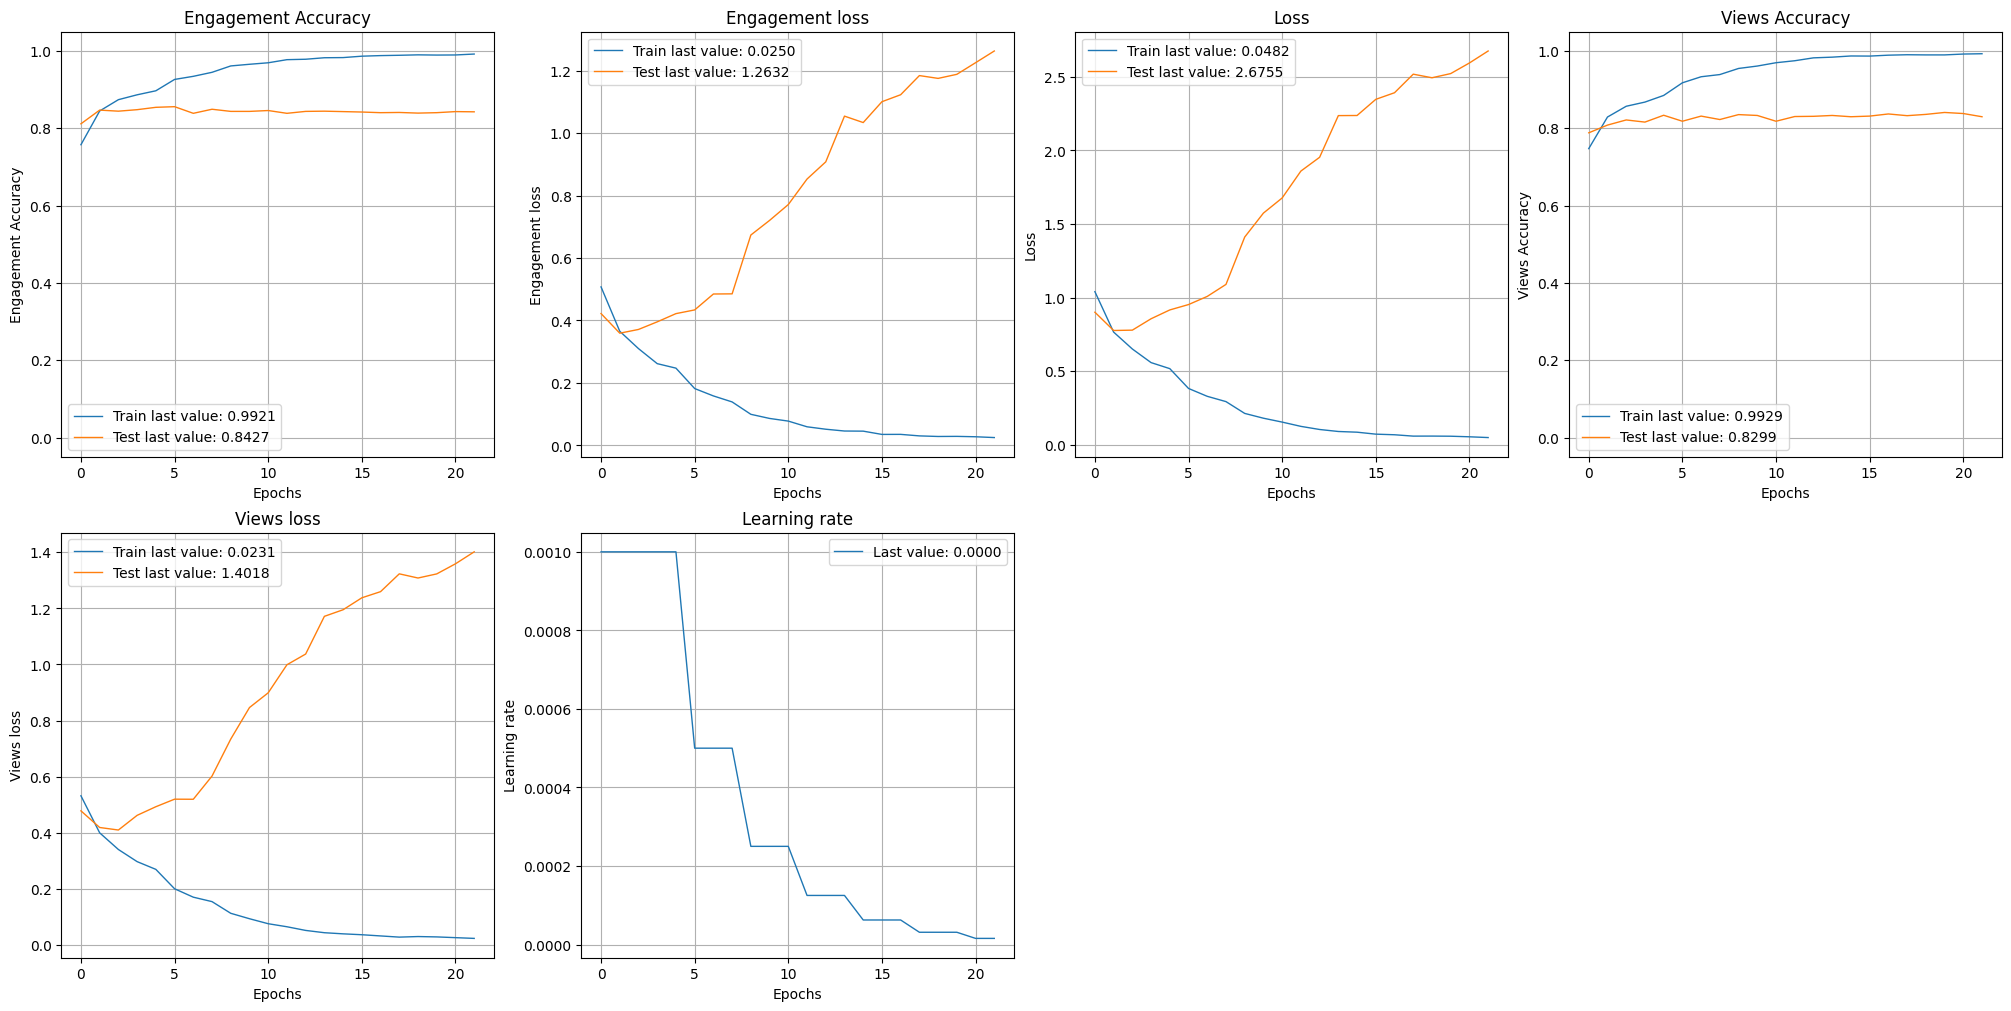

In [258]:
from plot_keras_history import plot_history

plot_history(history)

In [259]:
results = model.evaluate(
    X_test,
    {'views': y_views_test, 'engagement': y_engagement_test},
    verbose=0,
)
print(f"Test total loss:           {results[0]:.4f}")
print(f"Test views loss:           {results[1]:.4f}")
print(f"Test engagement loss:      {results[2]:.4f}")
print(f"Test views accuracy:       {results[3]:.4f}")
print(f"Test engagement accuracy:  {results[4]:.4f}")

Test total loss:           0.7664
Test views loss:           0.4027
Test engagement loss:      0.3665
Test views accuracy:       0.8444
Test engagement accuracy:  0.8187


In [260]:
from sklearn.metrics import accuracy_score

pred_views, pred_engagement = model.predict(X_test, verbose=0)
pred_views = pred_views.argmax(axis=1)
pred_engagement = pred_engagement.argmax(axis=1)

truth_views = y_views_test.argmax(axis=1)
truth_engagement = y_engagement_test.argmax(axis=1)

codes_train_v = y_views_train.argmax(axis=1)
codes_train_e = y_engagement_train.argmax(axis=1)

majority_v = int(pd.Series(codes_train_v).mode().iloc[0])
majority_e = int(pd.Series(codes_train_e).mode().iloc[0])
share_v = float(pd.Series(codes_train_v).value_counts(normalize=True).iloc[0])
share_e = float(pd.Series(codes_train_e).value_counts(normalize=True).iloc[0])

baseline_v = accuracy_score(truth_views, np.full(len(truth_views), majority_v, dtype=int))
baseline_e = accuracy_score(truth_engagement, np.full(len(truth_engagement), majority_e, dtype=int))
model_v = float(results[3])
model_e = float(results[4])

majority_v_pred = np.full(len(truth_views), majority_v, dtype=int)
majority_e_pred = np.full(len(truth_engagement), majority_e, dtype=int)
baseline_joint = float(np.mean(
    (majority_v_pred == truth_views) & (majority_e_pred == truth_engagement)
))
model_joint = float(np.mean(
    (pred_views == truth_views) & (pred_engagement == truth_engagement)
))

print(f"majority views_bin:        {majority_v}   share={share_v:.4f}")
print(f"majority engagement_bin:   {majority_e}   share={share_e:.4f}")
print()
print(f"baseline views_acc:        {baseline_v:.4f}")
print(f"model    views_acc:        {model_v:.4f}")
print(f"model views improvement:        {model_v - baseline_v:.4}")
print(f"baseline engagement_acc:   {baseline_e:.4f}")
print(f"model    engagement_acc:   {model_e:.4f}")
print(f"model engagement improvement:        {model_e - baseline_e:.4}")

print()
print(f"baseline joint_acc:        {baseline_joint:.4f}")
print(f"model    joint_acc:        {model_joint:.4f}")

print(f"model joint improvement:        {model_joint - baseline_joint:.4}")

majority views_bin:        0   share=0.6277
majority engagement_bin:   0   share=0.6347

baseline views_acc:        0.6179
model    views_acc:        0.8444
model views improvement:        0.2265
baseline engagement_acc:   0.6436
model    engagement_acc:   0.8187
model engagement improvement:        0.1751

baseline joint_acc:        0.5789
model    joint_acc:        0.7695
model joint improvement:        0.1906


### PCA

In [279]:
from sklearn.decomposition import PCA

pca_df = df_copy.copy().drop(columns=['views','engagement'])

pca = PCA()
pca.fit(pca_df)

PCA()

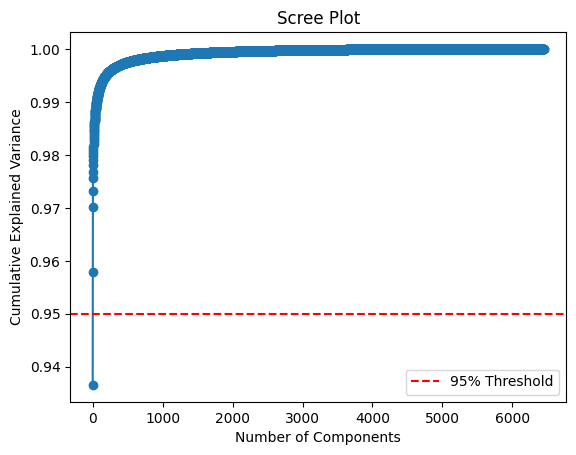

In [280]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot the scree plot
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Threshold')
plt.legend()
plt.show()

In [288]:
N_COMPONENTS = 10
TOP_FEATURES  = 10

explained = pd.Series(
    pca.explained_variance_ratio_[:N_COMPONENTS],
    index=[f"PC_{i+1}" for i in range(N_COMPONENTS)],
    name="explained_variance_ratio",
)
print("Top components by explained variance:")
print(explained.round(4).to_string())
print()

for i in range(N_COMPONENTS):
    name = f"PC_{i+1}"
    loadings = components_df.loc[name]
    ranked = loadings.sort_values(key=lambda s: s.abs(), ascending=False).head(TOP_FEATURES)
    print(
        f"== {name}  "
        f"(explains {pca.explained_variance_ratio_[i] * 100:.2f}% of variance) =="
    )
    for feature, weight in ranked.items():
        print(f"  {feature:<60s}  {weight:+.4f}")
    print()

Top components by explained variance:
PC_1     0.9366
PC_2     0.0212
PC_3     0.0124
PC_4     0.0029
PC_5     0.0025
PC_6     0.0012
PC_7     0.0012
PC_8     0.0009
PC_9     0.0008
PC_10    0.0006

== PC_1  (explains 93.66% of variance) ==
  duration_seconds                                              +0.9999
  description_cluster                                           -0.0049
  title_cluster                                                 +0.0049
  json_tone_pride                                               +0.0048
  json_content_theme_player story                               +0.0039
  json_tone_wholesome                                           +0.0037
  json_format_access_interview                                  +0.0036
  json_audio_format_voice                                       +0.0036
  json_content_theme_run                                        -0.0032
  json_content_theme_haka                                       +0.0031

== PC_2  (explains 2.12% of variance) 